<a href="https://colab.research.google.com/github/tuhaovan917-ship-it/thuc_hanh_deeplearning/blob/main/buoi4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Auto Encoder

## Tải file lên môi trường colab

In [ ]:
import pandas as pd

# The file kddcup.data_10_percent.gz is already available in /content/

# Đặt tên cột
cols = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land',
    'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised',
    'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack_type'
]

# Đọc trực tiếp từ file .gz
df = pd.read_csv('/content/kddcup.data_10_percent.gz', header=None, names=cols)

# Kiểm tra thành quả
print(df.head())

   duration protocol_type service flag  src_bytes  dst_bytes  land  \
0         0           tcp    http   SF        181       5450     0   
1         0           tcp    http   SF        239        486     0   
2         0           tcp    http   SF        235       1337     0   
3         0           tcp    http   SF        219       1337     0   
4         0           tcp    http   SF        217       2032     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                   9   
1               0       0    0  ...                  19   
2               0       0    0  ...                  29   
3               0       0    0  ...                  39   
4               0       0    0  ...                  49   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                     1.0                     0.0   
1                     1.0                     0.0   
2                     1.0                     0.0   
3           

## Lọc dữ liệu

In [ ]:
# Lọc lấy tất cả các dòng có attack_type là 'normal'
df_normal = df[df['attack_type'] == 'normal.']

# Bỏ cột nhãn 'attack_type' vì Autoencoder chỉ học trên dữ liệu bình thường
df_normal = df_normal.drop('attack_type', axis=1)

print('Số lượng bản ghi bình thường:', len(df_normal))
print('Số lượng cột còn lại:', df_normal.shape[1])

Số lượng bản ghi bình thường: 97278
Số lượng cột còn lại: 41


## Thực hiện One-Hot Encoding

In [ ]:
# Chuyển các cột chữ thành các cột nhị phân (0 hoặc 1)
df_encoded = pd.get_dummies(df_normal, columns=['protocol_type', 'service', 'flag'])

# Kiểm tra thử kết quả
print("Số lượng cột sau khi encoding:", df_encoded.shape[1])
print(df_encoded.head())

Số lượng cột sau khi encoding: 75
   duration  src_bytes  dst_bytes  land  wrong_fragment  urgent  hot  \
0         0        181       5450     0               0       0    0   
1         0        239        486     0               0       0    0   
2         0        235       1337     0               0       0    0   
3         0        219       1337     0               0       0    0   
4         0        217       2032     0               0       0    0   

   num_failed_logins  logged_in  num_compromised  ...  service_urp_i  \
0                  0          1                0  ...          False   
1                  0          1                0  ...          False   
2                  0          1                0  ...          False   
3                  0          1                0  ...          False   
4                  0          1                0  ...          False   

   flag_OTH  flag_REJ  flag_RSTO  flag_RSTR  flag_S0  flag_S1  flag_S2  \
0     False     False     

## Chuẩn hóa dữ liệu

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 1. Chuyển True/False thành 1/0
df_encoded = df_encoded.astype(int)

# 2. Chuẩn hóa về [0, 1]
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_encoded)

# 3. Kiểm tra lại lần cuối
print('Dữ liệu sau khi chuẩn hóa, hình dạng:', data_scaled.shape)
print('Giá trị nhỏ nhất/lớn nhất:', data_scaled.min(), data_scaled.max())

Dữ liệu sau khi chuẩn hóa, hình dạng: (97278, 75)
Giá trị nhỏ nhất/lớn nhất: 0.0 1.0


## Chia dữ liệu thành 80% train, 20% test

In [ ]:
from sklearn.model_selection import train_test_split

# Tách 80% train, 20% test
train_data, test_data = train_test_split(data_scaled, test_size=0.2, random_state=42)

## Xây dựng kiến trúc Autoencoder

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# Lớp input
input_dim = 75
input_layer = layers.Input(shape=(input_dim,))

# Encoder: Nén dữ liệu xuống không gian ẩn (ví dụ: từ 75 xuống  32 rồi 16)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='relu')(encoded)
encoded = layers.Dense(16, activation='relu')(encoded)

# Decoder: Tái tạo lại từ không gian ẩn lên 75
decoded = layers.Dense(32, activation='relu')(encoded)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dense(75, activation='sigmoid')(decoded)

# Tạo mô hình
autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse') # Dùng Mean Squared Error cho việc tái tạo
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 75)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 75)             │         4,875 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,003 (58.61 KB)

 Trainable params: 15,003 (58.61 KB)

 Non-trainable params: 0 (0.00 B)

## Huấn luyện mô hình

In [ ]:
history = autoencoder.fit(
    train_data,         # Dữ liệu đầu vào
    train_data,         # Dữ liệu đầu ra
    epochs=20,           # Số lượng vòng lặp (mỗi epoch mô hình sẽ quét qua toàn bộ dữ liệu)
    batch_size=512,      # Số lượng mẫu mỗi lần cập nhật trọng số
    shuffle=True,        # Xáo trộn dữ liệu để mô hình học tốt hơn
    validation_split=0.2 # Dùng 20% dữ liệu để kiểm tra chéo trong khi học
)

Epoch 1/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0687 - val_loss: 0.0151
Epoch 2/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0124 - val_loss: 0.0082
Epoch 3/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0058 - val_loss: 0.0045
Epoch 4/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0042 - val_loss: 0.0037
Epoch 5/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0035 - val_loss: 0.0032
Epoch 6/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0032 - val_loss: 0.0030
Epoch 7/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0029 - val_loss: 0.0028
Epoch 8/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0028 - val_loss: 0.0027
Epoch 9/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 10/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 11/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 12/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/ste

## Test

608/608 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


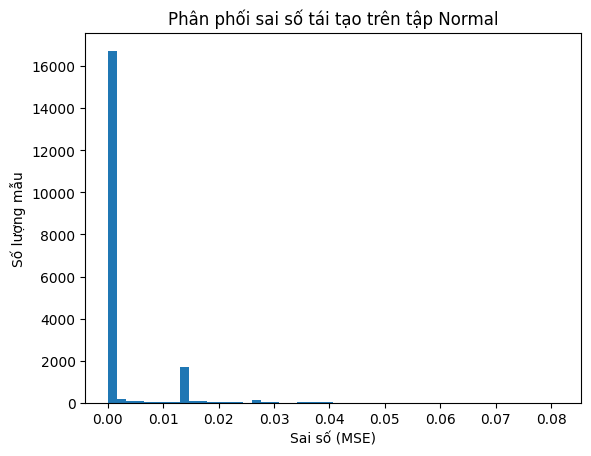

Ngưỡng phát hiện bất thường là: 0.01962927961359342


In [ ]:
import numpy as np

# 1. Dự đoán trên tập test
test_predictions = autoencoder.predict(test_data)

# 2. Tính sai số (MSE) cho từng dòng
mse = np.mean(np.power(test_data - test_predictions, 2), axis=1)

# 3. Xem phân phối sai số để chọn ngưỡng
import matplotlib.pyplot as plt
plt.hist(mse, bins=50)
plt.title("Phân phối sai số tái tạo trên tập Normal")
plt.xlabel("Sai số (MSE)")
plt.ylabel("Số lượng mẫu")
plt.show()

# 4. Tính ngưỡng (ví dụ: lấy trung bình + 3 lần độ lệch chuẩn)
threshold = np.mean(mse) + 3 * np.std(mse)
print(f"Ngưỡng phát hiện bất thường là: {threshold}")

## Chọn ngưỡng và thử nghiệm

In [ ]:
# Tính ngưỡng: lấy trung bình + 3 lần độ lệch chuẩn
threshold = np.mean(mse) + 3 * np.std(mse)
print(f"Ngưỡng phát hiện bất thường: {threshold}")

Ngưỡng phát hiện bất thường: 0.01962927961359342


In [ ]:
# Giả sử bạn muốn kiểm tra trên một phần dữ liệu có lẫn tấn công
# Nếu bạn chưa tách riêng, hãy dùng trực tiếp df_encoded (đã chuẩn hóa) để thử nghiệm

# 1. Chuẩn bị toàn bộ dữ liệu để dự đoán
# Lấy các cột đặc trưng từ df, bỏ cột nhãn 'attack_type'
df_features_all = df.drop('attack_type', axis=1)

# Áp dụng One-Hot Encoding cho toàn bộ dữ liệu
# Đảm bảo các cột categorical giống như khi huấn luyện
categorical_cols = ['protocol_type', 'service', 'flag']
df_encoded_all = pd.get_dummies(df_features_all, columns=categorical_cols)

# Rất quan trọng: Đảm bảo các cột của df_encoded_all khớp với các cột mà mô hình đã được huấn luyện
# (tức là các cột của df_encoded ban đầu). df_encoded.columns là các cột sau khi one-hot encoding của dữ liệu bình thường.
missing_cols = set(df_encoded.columns) - set(df_encoded_all.columns)
for c in missing_cols:
    df_encoded_all[c] = 0
# Sắp xếp lại các cột để đảm bảo thứ tự khớp với df_encoded
df_encoded_all = df_encoded_all[df_encoded.columns]

# Chuyển True/False thành 1/0
df_encoded_all = df_encoded_all.astype(int)

# 2. Chuẩn hóa toàn bộ dữ liệu bằng scaler đã được fit trên dữ liệu bình thường
data_scaled_full = scaler.transform(df_encoded_all)

# 3. Tính sai số cho toàn bộ dữ liệu (cả bình thường và tấn công)
full_data_pred = autoencoder.predict(data_scaled_full)
mse_all = np.mean(np.power(data_scaled_full - full_data_pred, 2), axis=1)

# 4. Gán nhãn dựa trên ngưỡng
# Nếu MSE > threshold, gán là 1 (tấn công), ngược lại là 0 (bình thường)
predictions = [1 if e > threshold else 0 for e in mse_all]

# 5. Thống kê xem mô hình bắt được bao nhiêu cuộc tấn công
import pandas as pd
df_results = pd.DataFrame({'MSE': mse_all, 'Anomaly': predictions})

print("Số lượng bản ghi bị gắn cờ là tấn công:", df_results['Anomaly'].sum())
print("Số lượng bản ghi được coi là bình thường:", len(df_results) - df_results['Anomaly'].sum())

15439/15439 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step
Số lượng bản ghi bị gắn cờ là tấn công: 395849
Số lượng bản ghi được coi là bình thường: 98172


In [ ]:
# Gắn lại nhãn thật vào bảng kết quả
# (Giả sử df['attack_type'] là cột nhãn gốc)
df_results['True_Label'] = df['attack_type'].values

# Xem thử mô hình đã bắt được bao nhiêu cuộc tấn công thật
# Bảng này sẽ cho bạn biết: Trong số những dòng được đoán là 'tấn công', bao nhiêu là đúng?
print(pd.crosstab(df_results['True_Label'], df_results['Anomaly']))

Anomaly               0       1
True_Label                     
back.              2110      93
buffer_overflow.      1      29
ftp_write.            0       8
guess_passwd.         0      53
imap.                 6       6
ipsweep.             90    1157
land.                 0      21
loadmodule.           2       7
multihop.             0       7
neptune.              0  107201
nmap.                26     205
normal.           95477    1801
perl.                 0       3
phf.                  3       1
pod.                  5     259
portsweep.            1    1039
rootkit.              5       5
satan.              128    1461
smurf.              255  280535
spy.                  1       1
teardrop.             7     972
warezclient.         55     965
warezmaster.          0      20


# RNN

## Nạp thư viện

In [ ]:
from pandas import read_csv
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt

## Tạo hàm định nghĩa mô hình RNN

In [ ]:
#hidden_unuits: 2 blocks
#dense_units: 1 block
#input_shappe: (time steeps x features)
#activation: linear f(x) = x
def create_RNN(hidden_units, dense_units, input_shape, activation):
  model = Sequential()
  model.add(SimpleRNN(hidden_units, input_shape=input_shape, activation=activation[0]))
  model.add(Dense(dense_units, activation=activation[1]))
  model.compile(optimizer='adam', loss='mean_square_error')
  return model

demo_RNN = create_RNN(2, 1, (3, 1), ['linear', 'linear'])

## Xem các tham số sinh bởi RNN

In [ ]:
wx = demo_RNN.get_weights()[0]
wh = demo_RNN.get_weights()[1]
bh = demo_RNN.get_weights()[2]
wy = demo_RNN.get_weights()[3]
by = demo_RNN.get_weights()[4]

print('wx=', wx)
print('wh=', wh)
print('bh=', bh)
print('wy=', wy)
print('by=', by)

wx= [[-0.32608616  1.3405322 ]]
wh= [[-0.54729235  0.8369416 ]
 [ 0.8369416   0.54729223]]
bh= [0. 0.]
wy= [[-1.2563237 ]
 [-0.16316497]]
by= [0.]


## Tính vector hidden cho tầng recurrent

In [ ]:
# he is initialized to zero vector
x = np.array([1, 2, 3])
# Reshape the input to the required sample_size x time_steps x features
x_input = np.reshape(x, (1, 3, 1))

y_predict_model = demo_RNN.predict(x_input)

m = 2
h0 = np.zeros(m)
h1 = np.dot(x[0], wx) + bh + h0
h2 = np.dot(x[1], wx) + np.dot(h1, wh) + bh
h3 = np.dot(x[2], wx) + np.dot(h2, wh) + bh

o3 = np.dot(h3, wy) + by

print('h1:', h1)
print('h2:', h2)
print('h3:', h3)
print('Prediction of model:', y_predict_model)
print('Prediction from computation:', o3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
h1: [[-0.32608616  1.34053218]]
h2: [[0.64823929 3.14181214]]
h3: [[1.29647839 6.28362436]]
Prediction of model: [[-2.654064]]
Prediction from computation: [[-2.65406392]]


# Áp dụng RNN cho ứng dụng thực tế

## Đọc dữ liệu

In [ ]:
from pandas import read_csv
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import math

def get_train_test(url, split_percent=0.8):
    # Đọc dữ liệu từ url
    df = read_csv(url, usecols=[1], engine='python')
    data = np.array(df.values.astype('float32'))

    # Chuẩn hóa dữ liệu về khoảng [0, 1]
    scaler = MinMaxScaler(feature_range=(0, 1))
    data = scaler.fit_transform(data).flatten()

    # Chia dữ liệu thành tập train và test
    n = len(data)
    split = int(n * split_percent)
    train_data = data[range(split)]
    test_data = data[split:]

    return train_data, test_data, data

# Đường dẫn bộ dữ liệu
sunspots_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'

# Gọi hàm để lấy dữ liệu
train_data, test_data, data = get_train_test(sunspots_url)

print("Đã tải và xử lý xong dữ liệu.")
print("Số lượng dữ liệu train:", len(train_data))
print("Số lượng dữ liệu test:", len(test_data))

Đã tải và xử lý xong dữ liệu.
Số lượng dữ liệu train: 2256
Số lượng dữ liệu test: 564


## Chuẩn bị dữ liệu cho RNN

In [ ]:
import numpy as np

# Hàm get_XY nhận tham số mảng 1 chiều và chuyển thành mảng input X và mục tiêu Y.
def get_XY(dat, time_steps):
    # Tạo chỉ số cho mảng mục tiêu (target)
    y_ind = np.arange(time_steps, len(dat), time_steps)
    Y = dat[y_ind]

    # Chuẩn bị dữ liệu X
    row_x = len(Y)
    X = dat[range(time_steps * row_x)]
    X = np.reshape(X, (row_x, time_steps, 1))

    return X, Y

# Sử dụng 12 time_steps để lấy dữ liệu cho 12 tháng
time_steps = 12

# Tạo tập huấn luyện và tập kiểm tra (sử dụng các biến train_data, test_data từ mục 3.1)
trainX, trainY = get_XY(train_data, time_steps)
testX, testY = get_XY(test_data, time_steps)

print("Đã chuẩn bị xong dữ liệu:")
print("Hình dạng trainX:", trainX.shape)
print("Hình dạng trainY:", trainY.shape)

Đã chuẩn bị xong dữ liệu:
Hình dạng trainX: (187, 12, 1)
Hình dạng trainY: (187,)


## Tạo RNN model và huấn luyện

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN

# Redefine create_RNN with the correct loss function identifier
def create_RNN(hidden_units, dense_units, input_shape, activation):
  model = Sequential()
  model.add(SimpleRNN(hidden_units, input_shape=input_shape, activation=activation[0]))
  model.add(Dense(dense_units, activation=activation[1]))
  model.compile(optimizer='adam', loss='mse') # Corrected: 'mean_square_error' to 'mse'
  return model

model = create_RNN(hidden_units=3, dense_units=1, input_shape=(time_steps,1), activation=['tanh', 'tanh'])
model_fit = model.fit(trainX, trainY, epochs=20, verbose=1)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.1546
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1373 
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1206 
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1048 
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0908 
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0782 
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0675 
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0573 
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0494 
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0427 
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0376 
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0339 
Epoch 13/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0313 
Epoch 14/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0297 
Epoch 15/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0286 
Epoch 16/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/

## Hàm tính hiệu quả model

In [ ]:
import math
from sklearn.metrics import mean_squared_error

def print_error(trainY, testY, train_predict, test_predict):
    # Tính RMSE
    train_rmse = math.sqrt(mean_squared_error(trainY, train_predict))
    test_rmse = math.sqrt(mean_squared_error(testY, test_predict))

    # In kết quả RMSE
    print('Train RMSE: %.3f RMSE' % (train_rmse))
    print('Test RMSE: %.3f RMSE' % (test_rmse))

# Thực hiện dự báo trên tập train và test
train_predict = model.predict(trainX)
test_predict = model.predict(testX)

# Gọi hàm để in lỗi
print_error(trainY, testY, train_predict, test_predict)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Train RMSE: 0.161 RMSE
Test RMSE: 0.278 RMSE


## Đánh giá kết quả

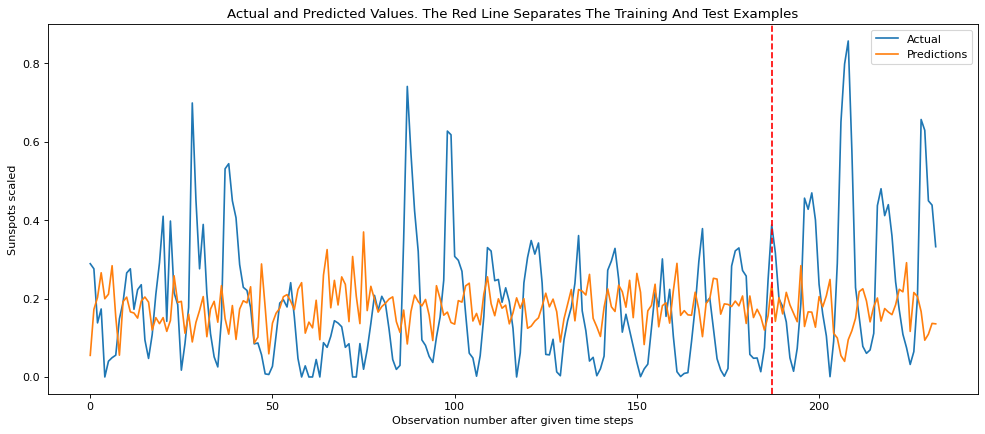

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Hàm vẽ kết quả dự báo
def plot_result(trainY, testY, train_predict, test_predict):
    # Kết hợp tập train và test để vẽ đồ thị liên tục
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)

    # Thiết lập kích thước đồ thị
    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual, label='Actual')
    plt.plot(range(rows), predictions, label='Predictions')

    # Vẽ đường phân tách giữa tập train và tập test
    plt.axvline(x=len(trainY), color='r', linestyle='--')

    plt.legend()
    plt.xlabel("Observation number after given time steps")
    plt.ylabel('Sunspots scaled')
    plt.title("Actual and Predicted Values. The Red Line Separates The Training And Test Examples")
    plt.show()

# Gọi hàm để vẽ đồ thị
# Lưu ý: Đảm bảo các biến trainY, testY, train_predict, test_predict đã được tạo ở các bước trước
plot_result(trainY, testY, train_predict, test_predict)